<a href="https://colab.research.google.com/github/sahapranta/medical-insurance-prediction/blob/main/Medical_Insurance_Cost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor


# warnings
import warnings
warnings.filterwarnings('ignore')

import pickle

In [27]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [28]:
df.shape

(1338, 7)

In [29]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [30]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# Data Preprocessing

In [32]:
df.drop_duplicates(inplace=True)

df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

X = df.drop("charges", axis=1)
y = df["charges"]

In [34]:
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region", "bmi_category"]

# Pipeline Creation

In [35]:
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [36]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numeric_features),
    ('cat', cat_transformer, categorical_features)
])

In [37]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Primary Model Selection

In [38]:
model = RandomForestRegressor(random_state=42)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

RandomForestRegressor is chosen because it is very easy to work that understand complex patterns automatically, does not overfit easily, and gives good results for this type of numeric prediction problem.

# Model Training

In [39]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'smoker', 'region',
                                                   'bmi_category'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [41]:
y_pred = pipeline.predict(X_test)

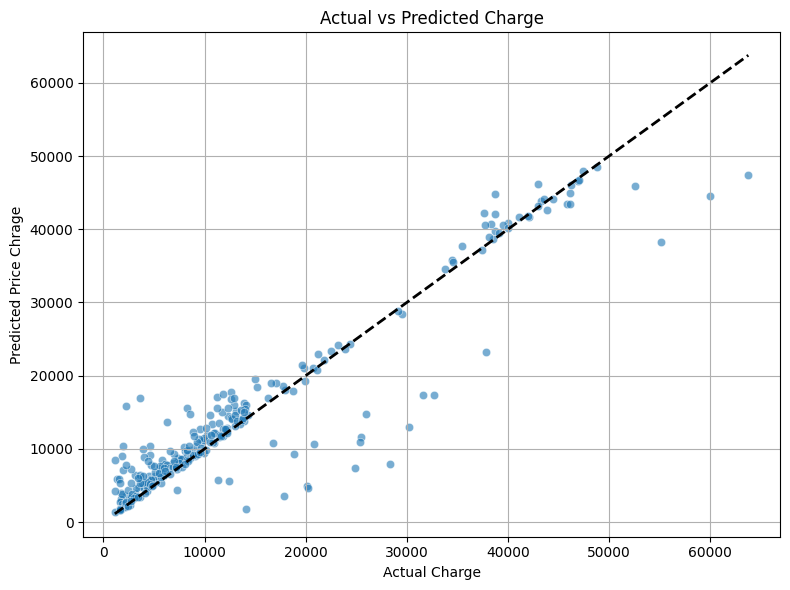

In [43]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Charge')
plt.ylabel('Predicted Price Chrage')
plt.title('Actual vs Predicted Charge')
plt.grid(True)
plt.tight_layout()
plt.show()

# Cross-Validation

In [44]:
cv_scores = cross_val_score(
    pipeline, X_train, y_train, cv=5, scoring="r2"
)
print("Average Score:", cv_scores.mean())
print("standard deviation:", cv_scores.std())

Average Score: 0.8224666456006989
standard deviation: 0.008896905625766158


# Hyperparameter Tuning

In [49]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

grid_model = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_model.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'bmi',
                                                                          'children']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'smoker',
                                                                          'region',
                                                                          'bmi_category'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='r2')

In [51]:
print("Best Score:", grid_model.best_score_)
print("Best Parameters:", grid_model.best_params_)

Best Score: 0.8290491908952096
Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}


# Best Model Selection

In [52]:
best_model = grid_model.best_estimator_
y_best_pred = best_model.predict(X_test)

In [53]:
print("MAE:", mean_absolute_error(y_test, y_best_pred))
print("RMSE:", mean_squared_error(y_test, y_best_pred))
print("R2:", r2_score(y_test, y_best_pred))

MAE: 2555.8670594168148
RMSE: 20293668.150607754
R2: 0.889561913199943


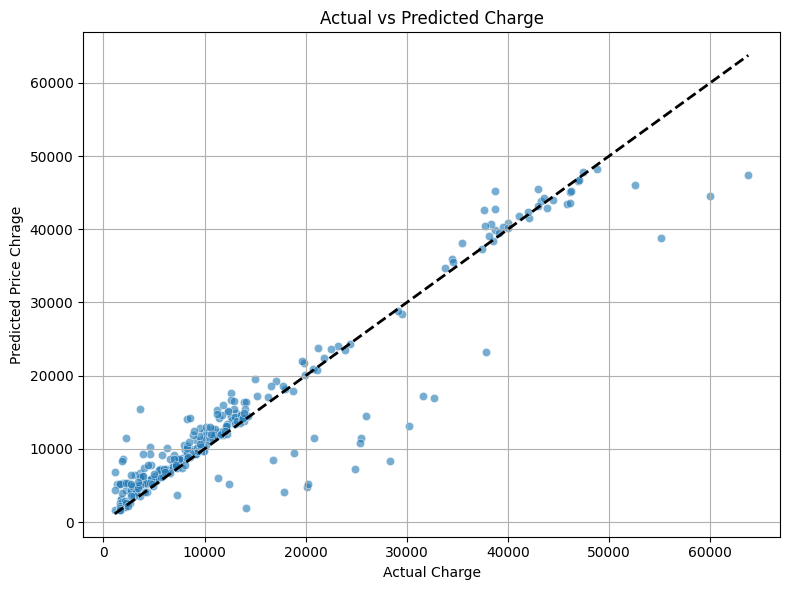

In [54]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_best_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Charge')
plt.ylabel('Predicted Price Chrage')
plt.title('Actual vs Predicted Charge')
plt.grid(True)
plt.tight_layout()
plt.show()

# Save the model

In [55]:
filename = 'grid_search_model.pkl'
pickle.dump(best_model, open(filename, 'wb'))